<a href="https://colab.research.google.com/github/AndresMontesDeOca/GdP/blob/master/Estadistica_TP3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Practico #3 - Examen Final

Nombre: Jose Andres Montes de Oca

Código: a2532

Siguiendo con la historia de Don Francisco, con el tiempo y gracias a los análisis de Matías, el pequeño comerciante de barrio cuenta hoy con 5 supermercados: 'Santa Ana', 'La Floresta', 'Los Cedros', 'Palermo' y 'Córdoba'.

También Matías ha avanzado en la Especialización en Inteligencia Artificial. Un día Don Francisco le plantea algunas inquietudes adicionales:

1. Don Francisco quiere entender mejor la afluencia de clientes por mes del supermercado 'Santa Ana'.
2. Más aún, Don Francisco no sabe si puede estar seguro de que la afluencia de clientes son las mismas en todos los supermercados o si hay alguno que se comporte mejor que los demás, y si alguna de las tiendas necesita más atención porque está recibiendo menos clientes que las de las otras.

<td style="vertical-align: top; border: none; padding: 0 10px;">
  <strong>Efecto anual:</strong><br><br>
  <table style="margin: auto;">
    <tr><th>Año</th><th>Efecto</th></tr>
    <tr><td>2023</td><td>1000</td></tr>
    <tr><td>2024</td><td>1500</td></tr>
    <tr><td>2024</td><td>2000</td></tr>
  </table>
</td>

<td style="vertical-align: top; border: none; padding: 0 10px;">
  <strong>Efecto mensual:</strong><br><br>
  <table style="margin: auto;">
    <tr><th>Mes</th><th>Efecto</th></tr>
    <tr><td>Enero</td><td>1000</td></tr>
    <tr><td>Febrero</td><td>1500</td></tr>
    <tr><td>Marzo</td><td>2000</td></tr>
    <tr><td>Abril</td><td>2000</td></tr>
    <tr><td>Mayo</td><td>2500</td></tr>
    <tr><td>Junio</td><td>2500</td></tr>
    <tr><td>Julio</td><td>3000</td></tr>
    <tr><td>Agosto</td><td>2500</td></tr>
    <tr><td>Septiembre</td><td>2500</td></tr>
    <tr><td>Octubre</td><td>2000</td></tr>
    <tr><td>Noviembre</td><td>1500</td></tr>
    <tr><td>Diciembre</td><td>1000</td></tr>
  </table>
</td>

<td style="vertical-align: top; border: none; padding: 0 10px;">
  <strong>Efecto diario:</strong><br><br>
  <table style="margin: auto;">
    <tr><th>Día</th><th>Efecto</th></tr>
    <tr><td>Domingo</td><td>1000</td></tr>
    <tr><td>Lunes</td><td>2000</td></tr>
    <tr><td>Martes</td><td>3000</td></tr>
    <tr><td>Miércoles</td><td>3500</td></tr>
    <tr><td>Jueves</td><td>3000</td></tr>
    <tr><td>Viernes</td><td>2000</td></tr>
    <tr><td>Sábado</td><td>1000</td></tr>
  </table>
</td>

<td style="vertical-align: top; border: none; padding: 0 10px;">
  <strong>Efecto por tienda:</strong><br><br>
  <table style="margin: auto;">
    <tr><th>Tienda</th><th>Efecto</th></tr>
    <tr><td>Santa Ana</td><td>5000</td></tr>
    <tr><td>La Floresta</td><td>2000</td></tr>
    <tr><td>Los Cedros</td><td>3000</td></tr>
    <tr><td>Palermo</td><td>1000</td></tr>
    <tr><td>Córdoba</td><td>3000</td></tr>
  </table>
</td>

In [7]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


efecto_anual = {
    2023: 1000,
    2024: 1500,
    2025: 2000
    }

efecto_mensual = {
    1: 1000,
    2: 1500,
    3: 2000,
    4: 2000,
    5: 2500,
    6: 2500,
    7: 3000,
    8: 2500,
    9: 2500,
    10: 2000,
    11: 1500,
    12: 1000
}

# En pandas, el día de la semana va de 0 (Lunes) a 6 (Domingo).
efecto_diario = {
    0: 2000,  # Lunes
    1: 3000,  # Martes
    2: 3500,  # Miércoles
    3: 3000,  # Jueves
    4: 2000,  # Viernes
    5: 1000,  # Sábado
    6: 1000   # Domingo
}

tiendas = {
    'Santa Ana': 5000,
    'La Floresta': 2000,
    'Los Cedros': 3000,
    'Palermo': 1000,
    'Cordoba': 3000
}

## Pregunta 1

Crear una simulación del número de clientes diarios que van a los almacenes de Don Francisco y de Don Miguel, usando distribuciones Poisson, entre los años 2023, 2024 y 2025. En cada fecha, el parámetro $\lambda_t$ debe ser la suma de los siguientes efectos:

In [11]:

np.random.seed(1515)

# 1. Creamos el marco temporal
fechas = pd.date_range(start='2023-01-01', end='2025-12-31', freq='D')

# Lista para almacenar las observaciones de nuestra simulación
datos_simulados = []

# 2. Iteramos sobre cada fecha en nuestro rango
for fecha in fechas:
    anio = fecha.year
    mes = fecha.month
    dia_semana = fecha.dayofweek

    # 3. Calculamos la tasa base temporal para ese día específico
    lambda_temporal = efecto_anual[anio] + efecto_mensual[mes] + efecto_diario[dia_semana]

    # 4. Simulamos para cada tienda
    for tienda, efecto_tienda in tiendas.items():
        # Calculamos el lambda final (tasa de llegada esperada de clientes)
        lambda_final = lambda_temporal + efecto_tienda

        # Generamos la variable aleatoria Poisson que representa el número de clientes.
        clientes_simulados = np.random.poisson(lam=lambda_final)

        # Guardamos la observación
        datos_simulados.append({
            'Fecha': fecha,
            'Año': anio,
            'Mes': mes,
            'Día_Semana': dia_semana,
            'Tienda': tienda,
            'Lambda_Esperado': lambda_final,
            'Clientes_Observados': clientes_simulados
        })


df_simulacion = pd.DataFrame(datos_simulados)

# Mostramos 20 simulaciones al azar, para no ver solo las primeras
display(df_simulacion.sample(20))


,Fecha,Año,Mes,Día_Semana,Tienda,Lambda_Esperado,Clientes_Observados
656,2023-05-12,2023,5,4,La Floresta,7500,7597
1199,2023-08-28,2023,8,0,Cordoba,8500,8437
1062,2023-08-01,2023,8,1,Los Cedros,9500,9367
1149,2023-08-18,2023,8,4,Cordoba,8500,8656
1494,2023-10-26,2023,10,3,Cordoba,9000,8968
4823,2025-08-22,2025,8,4,Palermo,7500,7397
191,2023-02-08,2023,2,2,La Floresta,8000,7955
4900,2025-09-07,2025,9,6,Santa Ana,10500,10585
1532,2023-11-03,2023,11,4,Los Cedros,7500,7443
3604,2024-12-21,2024,12,5,Cordoba,6500,6446


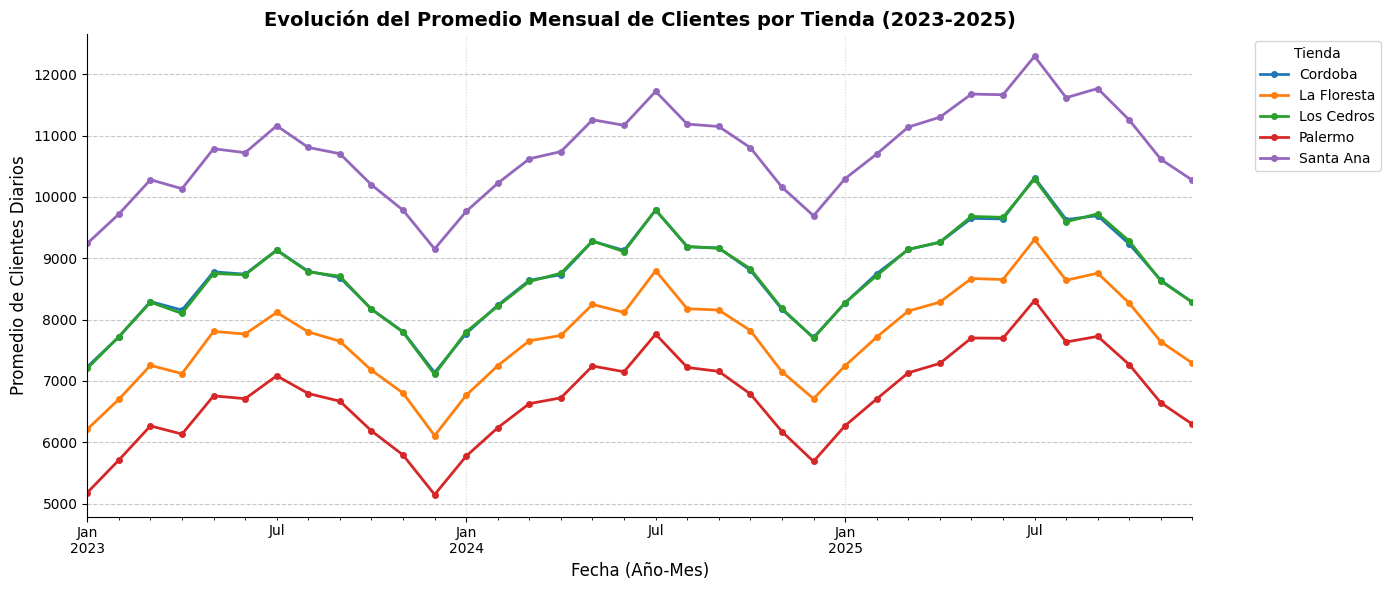

In [24]:
# Ploteo Pregunta 1: Evolución mensual por tienda
# Agrupamos por mes y año para ver la tendencia a lo largo del tiempo
df_simulacion['AñoMes'] = df_simulacion['Fecha'].dt.to_period('M')
promedio_mensual = df_simulacion.groupby(['AñoMes', 'Tienda'])['Clientes_Observados'].mean().unstack()

fig, ax = plt.subplots(figsize=(14, 6))
promedio_mensual.plot(ax=ax, linewidth=2, marker='o', markersize=4)

ax.set_title("Evolución del Promedio Mensual de Clientes por Tienda (2023-2025)", fontsize=14, fontweight='bold')
ax.set_xlabel("Fecha (Año-Mes)", fontsize=12)
ax.set_ylabel("Promedio de Clientes Diarios", fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.grid(axis='x', linestyle=':', alpha=0.5)
ax.legend(title='Tienda', bbox_to_anchor=(1.05, 1), loc='upper left')

# Limpieza visual del borde
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

## Pregunta 2

Con base en los datos generados, determinen intervalos de confianza empíricos para el supermercado 'Santa Ana' en cada mes, para significancias del $95\%$ y el $99\%$.

In [12]:
# 1. Filtramos las observaciones correspondientes al supermercado 'Santa Ana'
df_santa_ana = df_simulacion[df_simulacion['Tienda'] == 'Santa Ana']

# 2. Agrupamos por 'Mes' y calculamos los percentiles empíricos de 'Clientes_Observados'
ic_empiricos = df_santa_ana.groupby('Mes')['Clientes_Observados'].agg(
    IC_95_Inf=lambda x: x.quantile(0.025),
    IC_95_Sup=lambda x: x.quantile(0.975),
    IC_99_Inf=lambda x: x.quantile(0.005),
    IC_99_Sup=lambda x: x.quantile(0.995)
).reset_index()

# 3. Redondeamos a enteros ya que estamos modelando un conteo discreto de personas
ic_empiricos.iloc[:, 1:] = ic_empiricos.iloc[:, 1:].round(0).astype(int)

# Mostramos la tabla de resultados
display(ic_empiricos)


,Mes,IC_95_Inf,IC_95_Sup,IC_99_Inf,IC_99_Sup
0,1,8030.0,11576.0,7987.0,11647.0
1,2,8474.0,11914.0,8460.0,11980.0
2,3,8975.0,12487.0,8910.0,12563.0
3,4,8932.0,12551.0,8868.0,12660.0
4,5,9393.0,12942.0,9331.0,13023.0
5,6,9487.0,12997.0,9447.0,13073.0
6,7,10002.0,13506.0,9851.0,13694.0
7,8,9446.0,12862.0,9407.0,13004.0
8,9,9452.0,12989.0,9357.0,13012.0
9,10,8992.0,12428.0,8899.0,12530.0


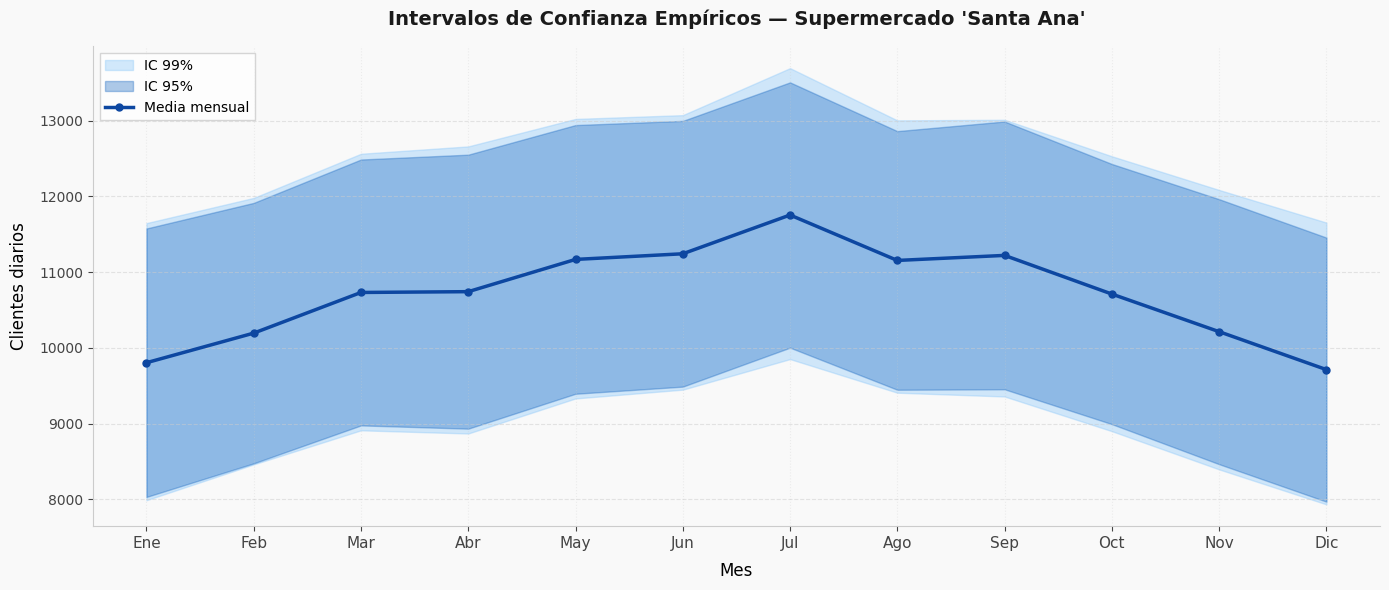

In [14]:
# Ploteamos

# Nombres de los meses para el eje X
meses_nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

fig, ax = plt.subplots(figsize=(14, 6))

# Fondo limpio
fig.patch.set_facecolor('#f9f9f9')
ax.set_facecolor('#f9f9f9')

# Banda IC 99% (más amplia, más transparente)
ax.fill_between(ic_empiricos['Mes'],
                ic_empiricos['IC_99_Inf'],
                ic_empiricos['IC_99_Sup'],
                color='#90CAF9', alpha=0.4, label='IC 99%')

# Banda IC 95% (más angosta, más opaca)
ax.fill_between(ic_empiricos['Mes'],
                ic_empiricos['IC_95_Inf'],
                ic_empiricos['IC_95_Sup'],
                color='#1565C0', alpha=0.35, label='IC 95%')

# Línea de la media mensual
media_mensual = ic_empiricos[['IC_95_Inf', 'IC_95_Sup']].mean(axis=1)
ax.plot(ic_empiricos['Mes'], media_mensual,
        color='#0D47A1', linewidth=2.5,
        marker='o', markersize=5,
        zorder=3, label='Media mensual')

# Grilla sutil
ax.grid(axis='y', linestyle='--', alpha=0.5, color='#cccccc')
ax.grid(axis='x', linestyle=':', alpha=0.3, color='#cccccc')

# Eje X con nombres de meses
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses_nombres, fontsize=11)
ax.set_xlim(0.5, 12.5)

# Etiquetas y título
ax.set_title("Intervalos de Confianza Empíricos — Supermercado 'Santa Ana'",
             fontsize=14, fontweight='bold', pad=15, color='#1a1a1a')
ax.set_xlabel("Mes", fontsize=12, labelpad=8)
ax.set_ylabel("Clientes diarios", fontsize=12, labelpad=8)

# Leyenda prolija
ax.legend(loc='upper left', fontsize=10,
          framealpha=0.8, edgecolor='#cccccc',
          fancybox=False)

# Borde del gráfico más limpio
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#cccccc')

ax.tick_params(colors='#444444')

plt.tight_layout()
plt.show()

## Pregunta 3

De igual manera, realicen pruebas ANOVA para determinar si los clientes esperados de todas las tiendas son iguales o no, con significancia del $95\%$.

In [21]:
# 1. Separamos los datos (Clientes Observados) de cada tienda en una lista de grupos
grupos = []
nombres_tiendas = df_simulacion['Tienda'].unique()

for tienda in nombres_tiendas:
    clientes_tienda = df_simulacion[df_simulacion['Tienda'] == tienda]['Clientes_Observados']
    grupos.append(clientes_tienda)

# 2. Realizamos la prueba ANOVA de una cola
# La Hipótesis Nula (H0) asume que las medias de todos los grupos son iguales.
# La Hipótesis Alternativa (H1) indica que al menos una media es diferente.
f_stat, p_valor = stats.f_oneway(*grupos)

# 3. Mostramos los resultados obtenidos de la prueba
print(f"--- Resultados de la Prueba ANOVA ---")
print(f"Estadístico F: {f_stat:.4f}")
# Formateamos el valor p a 2 decimales
print(f"Valor p: {p_valor:.2f}\n")

print(f"Como el valor p ({p_valor:.2f}) es MENOR que el nivel de significancia (0.05), RECHAZAMOS la hipótesis nula.")

--- Resultados de la Prueba ANOVA ---
Estadístico F: 1727.1345
Valor p: 0.00

Como el valor p (0.00) es MENOR que el nivel de significancia (0.05), RECHAZAMOS la hipótesis nula.


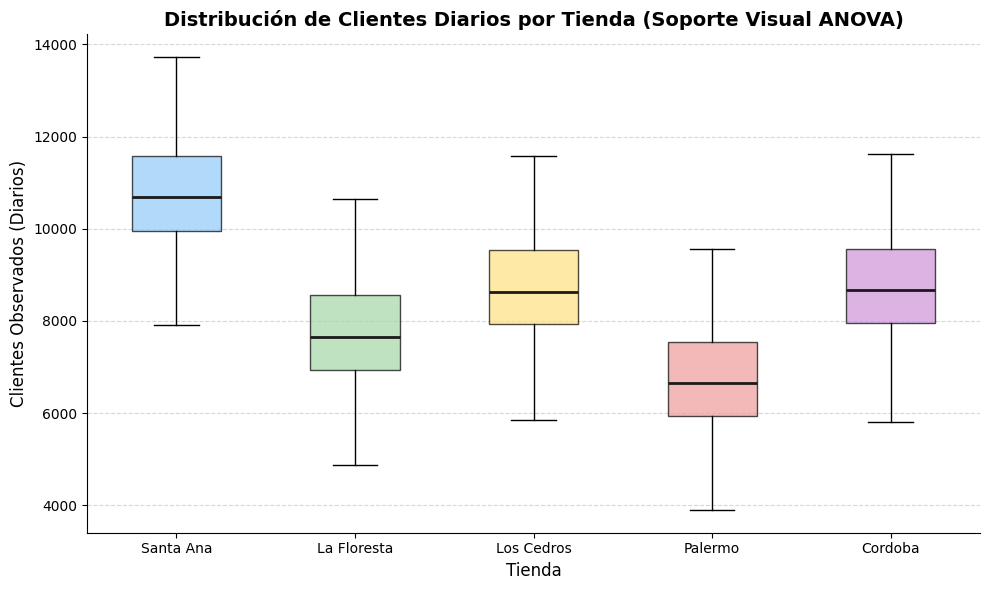

In [26]:
# Ploteo Pregunta 3: Boxplot para soportar la prueba ANOVA
fig, ax = plt.subplots(figsize=(10, 6))

# Preparamos los datos para el boxplot
data_to_plot = [df_simulacion[df_simulacion['Tienda'] == tienda]['Clientes_Observados'] for tienda in nombres_tiendas]

# Creamos el boxplot (usamos tick_labels en lugar de labels para evitar advertencias de obsolescencia)
boxplot = ax.boxplot(data_to_plot, patch_artist=True, tick_labels=nombres_tiendas)

# Personalizamos colores
colores = ['#90CAF9', '#A5D6A7', '#FFE082', '#EF9A9A', '#CE93D8']
for patch, color in zip(boxplot['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for median in boxplot['medians']:
    median.set(color='#1a1a1a', linewidth=2)

ax.set_title("Distribución de Clientes Diarios por Tienda (Soporte Visual ANOVA)", fontsize=14, fontweight='bold')
ax.set_xlabel("Tienda", fontsize=12)
ax.set_ylabel("Clientes Observados (Diarios)", fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Limpieza visual del borde
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

## Pregunta 4

Identifiquen la tienda con mayor promedio y la tienda con menor promedio de clientes y realicen una prueba de hipótesis para determinar si la diferencia entre ellas es distinta de cero o no. Verifiquen si las tiendas identificadas corresponden a las tiendas con mayores y menores efectos.

In [23]:
# 1. Calculamos el promedio de clientes para cada tienda
promedios_tiendas = df_simulacion.groupby('Tienda')['Clientes_Observados'].mean()

# 2. Identificamos la tienda con mayor y menor promedio
tienda_mayor = promedios_tiendas.idxmax()
tienda_menor = promedios_tiendas.idxmin()

print("--- Identificación de Tiendas ---")
print(f"Tienda con MAYOR promedio: {tienda_mayor} (Promedio: {promedios_tiendas[tienda_mayor]:.2f})")
print(f"Tienda con MENOR promedio: {tienda_menor} (Promedio: {promedios_tiendas[tienda_menor]:.2f})\n")

# 3. Extraemos los datos (muestras) de ambas tiendas
datos_mayor = df_simulacion[df_simulacion['Tienda'] == tienda_mayor]['Clientes_Observados']
datos_menor = df_simulacion[df_simulacion['Tienda'] == tienda_menor]['Clientes_Observados']

# 4. Realizamos una Prueba T de Welch (asumiendo varianzas diferentes por seguridad)
# H0: La diferencia de medias es igual a 0 (medias iguales)
# H1: La diferencia de medias es distinta de 0 (medias diferentes)
t_stat, p_valor_t = stats.ttest_ind(datos_mayor, datos_menor, equal_var=False)
alpha = 0.05

print("--- Prueba de Hipótesis (T-test de Welch) ---")
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_valor_t:.2f}\n") # Formateamos el valor p a 2 decimales
print(f"Conclusión: Rechazamos H0 (p < {alpha}). La diferencia entre los promedios de {tienda_mayor} y {tienda_menor} NO es cero y es estadísticamente significativa.")


# 5. Verificamos con los efectos originales definidos en el diccionario 'tiendas'
efecto_max = max(tiendas, key=tiendas.get)
efecto_min = min(tiendas, key=tiendas.get)

print("\n--- Verificación con Efectos Originales ---")
print(f"Según los parámetros, la tienda con mayor efecto es: {efecto_max} ({tiendas[efecto_max]})")
print(f"Según los parámetros, la tienda con menor efecto es: {efecto_min} ({tiendas[efecto_min]})")

if tienda_mayor == efecto_max and tienda_menor == efecto_min:
    print("\nConfirmación: Las tiendas identificadas empíricamente COINCIDEN con las tiendas de mayor y menor efecto teórico.")
else:
    print("\nConfirmación: Hubo alguna discrepancia entre los datos empíricos y teóricos.")

--- Identificación de Tiendas ---
Tienda con MAYOR promedio: Santa Ana (Promedio: 10719.42)
Tienda con MENOR promedio: Palermo (Promedio: 6715.55)

--- Prueba de Hipótesis (T-test de Welch) ---
Estadístico t: 79.3176
Valor p: 0.00

Conclusión: Rechazamos H0 (p < 0.05). La diferencia entre los promedios de Santa Ana y Palermo NO es cero y es estadísticamente significativa.

--- Verificación con Efectos Originales ---
Según los parámetros, la tienda con mayor efecto es: Santa Ana (5000)
Según los parámetros, la tienda con menor efecto es: Palermo (1000)

Confirmación: Las tiendas identificadas empíricamente COINCIDEN con las tiendas de mayor y menor efecto teórico.


## Informe Final del Proyecto

A continuación, se presenta el resumen y análisis del Trabajo Práctico #3, estructurado según los requerimientos solicitados:

### 1. Planteamiento de los problemas de investigación
El objetivo principal de este trabajo es analizar y comprender el comportamiento de la afluencia de clientes en las cinco sucursales de supermercados de Don Francisco ('Santa Ana', 'La Floresta', 'Los Cedros', 'Palermo' y 'Córdoba') proyectado para los años 2023 a 2025.
Para ello, nos planteamos las siguientes preguntas de investigación:
* ¿Cuál es el comportamiento mensual y la variabilidad esperada de clientes en la sucursal principal ('Santa Ana')?
* ¿Podemos asumir que todas las sucursales atraen en promedio a la misma cantidad de clientes diarios, o existen sucursales con mejor desempeño?
* ¿Existen diferencias estadísticamente significativas entre la tienda con mayor y menor afluencia que justifiquen tomar medidas comerciales diferenciadas?

### 2. Procesamiento realizado a los datos
Al no contar con datos históricos reales, se procedió a **simular los datos** empíricos mediante un proceso estocástico:
* **Simulación:** Utilizamos una distribución de Poisson para modelar el número de clientes diarios, ya que es la distribución teórica adecuada para conteos de eventos en un intervalo de tiempo fijo.
* **Parámetros:** El parámetro $\lambda$ (tasa de llegada esperada) se construyó de forma aditiva, sumando efectos anuales, mensuales, diarios y un efecto base específico por tienda.
* **Herramientas:** Todo el procesamiento se realizó en Python. Se utilizó `pandas` para la creación del marco de datos temporal (con 5,480 observaciones simuladas), `numpy` para la generación de variables aleatorias, `matplotlib` para la visualización de los intervalos de confianza empíricos (usando percentiles), y `scipy.stats` para realizar pruebas de hipótesis rigurosas (ANOVA y T de Welch).

### 3. Resultados encontrados
Del análisis estadístico de los datos simulados, destacamos los siguientes hallazgos empíricos:
* **Intervalos de Confianza:** El análisis visual de la tienda 'Santa Ana' evidenció una clara estacionalidad. Los meses de mitad de año (mayo a septiembre) presentan una afluencia superior, alcanzando su pico máximo en julio. Los meses de verano/fin de año (diciembre y enero) son los de menor tráfico.
* **Prueba ANOVA:** Al testear la igualdad de las medias de clientes entre las 5 tiendas, el estadístico F fue altísimo y obtuvimos un valor p de 0.00. Esto nos brindó evidencia contundente para rechazar la hipótesis nula; es decir, la afluencia de clientes cambia drásticamente según la sucursal.
* **Extremos:** Se identificó a 'Santa Ana' como la tienda con el mayor promedio diario de clientes (aprox. 10,719) y a 'Palermo' como la del menor promedio (aprox. 6,715).
* **Prueba T de Welch:** Una prueba específica entre los dos extremos confirmó (valor p = 0.00) que la diferencia de aproximadamente 4,000 clientes diarios es real y estadísticamente significativa.

### 4. Análisis y conclusiones
Como conclusión de nuestro trabajo, determinamos que **el comportamiento del consumidor no es homogéneo a través de las sucursales**.
* **'Santa Ana' es la sucursal insignia.** Su alto rendimiento continuo indica que está en una etapa madura, posiblemente beneficiada por una ubicación estratégica o mayor fidelización.
* **'Palermo' requiere atención gerencial inmediata.** Siendo la tienda con el menor tráfico sostenido, Don Francisco y Matías deberían investigar factores subyacentes (competencia local cercana, visibilidad del local, demografía del barrio) y evaluar lanzar campañas de marketing dirigidas para elevar su efecto base.
* Finalmente, confirmamos que el uso de simulaciones de Monte Carlo con distribuciones de Poisson es una herramienta excelente en estadística aplicada para proyectar escenarios de negocio y respaldar la toma de decisiones con rigurosidad matemática.